In [5]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------- ----------------------------- 0.8/3.0 MB 3.9 MB/s eta 0:00:01
     -------------------- ------------------- 1.6/3.0 MB 3.9 MB/s eta 0:00:01
     ------------------------------- -------- 2.4/3.0 MB 4.0 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 4.1 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pypro

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import yfinance as yf
import datetime as dt

### Price and return behaviour

objectives:
- Get daily price data for last 5Y
- Compute daily returns + cumulative returns
- Plot price over time (ine graph) + cumulative returns (histogram)

In [7]:
# Set date range for analysis
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=365*5)  

end_date, start_date


(datetime.datetime(2026, 1, 6, 13, 54, 35, 357876),
 datetime.datetime(2021, 1, 7, 13, 54, 35, 357876))

In [8]:
# Download historical stock data for TTWO
stocks = ['TTWO']
data = yf.download(stocks, start=start_date, end=end_date)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TTWO,TTWO,TTWO,TTWO,TTWO
Date,,,,,
2021-01-07,208.009995,208.610001,203.199997,204.389999,944200
2021-01-08,210.429993,211.440002,207.630005,209.070007,899700
2021-01-11,206.539993,209.130005,206.080002,208.479996,839800
2021-01-12,199.149994,207.130005,198.860001,206.820007,1596700
2021-01-13,199.500000,202.389999,197.000000,198.449997,1281400


In [9]:
# Select 'Close' prices
close_prices = data['Close']
close_prices.head()

Ticker,TTWO
Date,
2021-01-07,208.009995
2021-01-08,210.429993
2021-01-11,206.539993
2021-01-12,199.149994
2021-01-13,199.500000


In [11]:
# Calculate daily returns
log_daily_returns = np.log(close_prices/close_prices.shift(1))
log_daily_returns.head()


Ticker,TTWO
Date,
2021-01-07,NaN
2021-01-08,0.011567
2021-01-11,-0.018659
2021-01-12,-0.036436
2021-01-13,0.001756


<Axes: title={'center': 'Daily returns 5Y'}, xlabel='Date'>

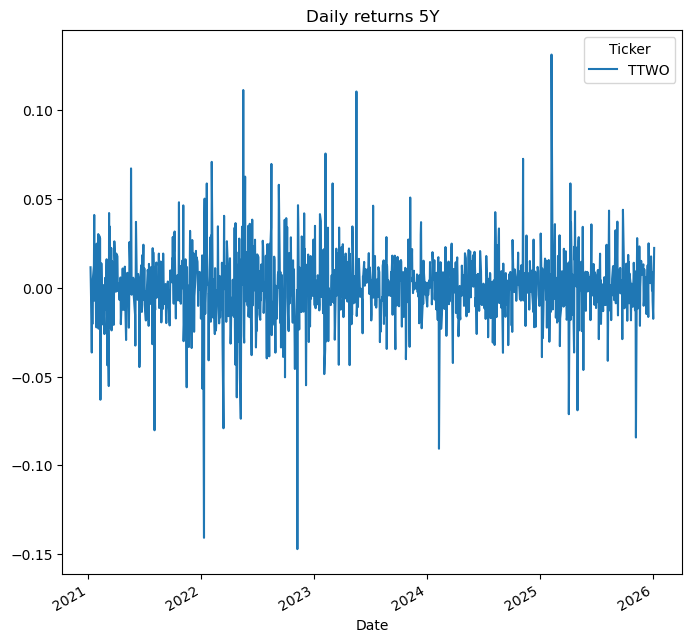

In [12]:
# Plot daily returns
log_daily_returns.plot(title='Daily returns 5Y',figsize=(8,8))

In [13]:
# Calculate cumulative returns

cumulative_data = log_daily_returns.cumsum()
cumulative_data.head()

Ticker,TTWO
Date,
2021-01-07,NaN
2021-01-08,0.011567
2021-01-11,-0.007092
2021-01-12,-0.043528
2021-01-13,-0.041772


<Axes: title={'center': 'Cumulative returns 5Y'}, xlabel='Date'>

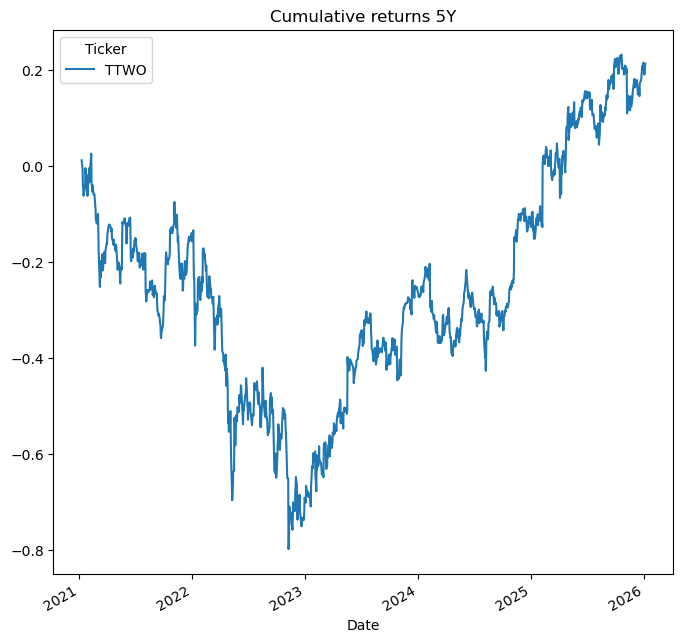

In [15]:
# Plot cumulative returns
cumulative_data.plot(title='Cumulative returns 5Y',figsize=(8,8))

### Downside analysis

Objectives:

- Identify the worst 5 daily returns
- Identify the Worst monthly period
- Plot returns around worst month


In [16]:
log_daily_returns.sort_values('TTWO', ascending=False)

Ticker,TTWO
Date,
2025-02-07,0.131310
2022-05-17,0.111355
2023-05-18,0.110522
2023-02-07,0.075602
2024-11-07,0.072619
...,...
2025-11-07,-0.084278
2024-02-09,-0.090598
2022-01-10,-0.140744


In [36]:
# wmp = worst monthly period
wmp_df = log_daily_returns.copy()
wmp_df.index = pd.to_datetime(wmp_df.index)

monthly_log_returns = wmp_df['TTWO'].resample('MS').sum()

worst_month = monthly_log_returns.idxmin()
worst_month

Timestamp('2022-04-01 00:00:00')

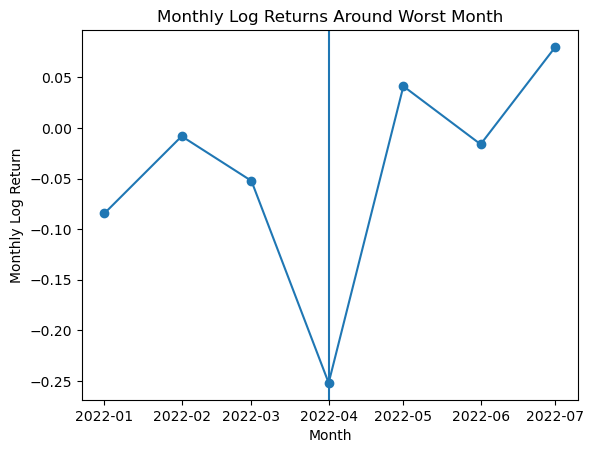

In [38]:
# Histogram of monthly period +- 3months

window = monthly_log_returns.loc[
    worst_month - pd.DateOffset(months=3) :
    worst_month + pd.DateOffset(months=3)                               
]

x = range(len(window))
x = [i - x[len(x)//2] for i in x]

plt.figure()
plt.plot(window.index, window.values, marker='o')
plt.axvline(worst_month)
plt.title("Monthly Log Returns Around Worst Month")
plt.xlabel("Month")
plt.ylabel("Monthly Log Return")
plt.show()


### VaR Analysis using the Monte Carlo Method

In [20]:
returns = log_daily_returns['TTWO'].dropna()

mean = returns.mean()
std_dev = returns.std()

np.random.seed(42)

trading_days = 21
n_runs = 100000
c_interval=0.99

In [21]:
simulated_daily = np.random.normal(
    loc=mean,
    scale=std_dev,
    size=(n_runs, trading_days)
)

simulated_monthly = simulated_daily.sum(axis=1)

In [23]:
initial_value = 100000

portfolio_values = initial_value *np.exp(simulated_monthly)
pnl = portfolio_values - initial_value

In [24]:
VaR_mc = -np.percentile(pnl, (1-c_interval)*100)
VaR_mc

np.float64(19158.445100157525)

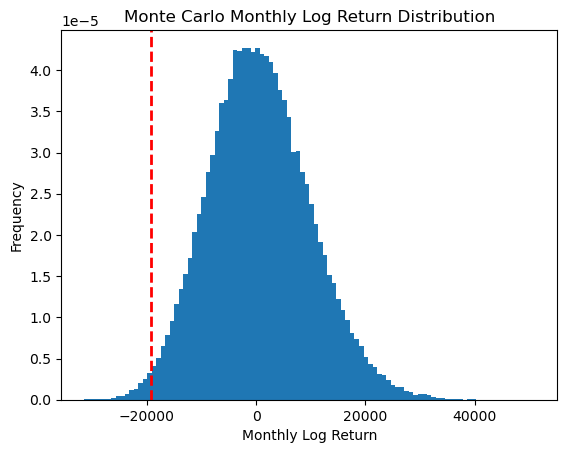

In [27]:
plt.figure()
plt.hist(pnl, bins=100,density=True)
plt.axvline(-VaR_mc, color='r', linestyle='dashed', linewidth=2, label='99% VaR')
plt.title("Monte Carlo Monthly Log Return Distribution")
plt.xlabel("Monthly Log Return")
plt.ylabel("Frequency")
plt.show()


### Monte Carlo Value at Risk (VaR)

To quantify downside risk over a realistic holding period, a Monte Carlo Value at Risk (VaR) analysis was performed using daily log returns for TTWO.

Daily log returns were assumed to be normally distributed, with parameters estimated from historical data. Using these parameters, 100,000 simulated return paths were generated over a 21-trading-day horizon. Monthly log returns were obtained by summing simulated daily returns, which were then converted into portfolio profit and loss (PnL) assuming an initial position value of $100,000.

The 99% confidence VaR was calculated as the 1st percentile of the simulated PnL distribution. This represents the expected loss that should not be exceeded in 99% of cases over a one-month period, under normal market conditions.

The Monte Carlo VaR estimate indicates a potential one-month loss of approximately $19,000 at the 99% confidence level. This shows the asymmetric downside risk inherent in a hit-driven stock such as TTWO, particularly in periods of elevated uncertainty surrounding major releases.

This analysis compliments the stock memo by providing a probabilistic measure of downside risk consistent with the investment horizon and portfolio positioning.
